In [1]:
import pandas as pd
import numpy as np

In [3]:
from google.colab import files
uploaded = files.upload()

Saving Cleeveland_Dataset_no_thal.csv to Cleeveland_Dataset_no_thal (1).csv


In [6]:
filename = list(uploaded.keys())[0]
df = pd.read_csv(filename)
print("Initial shape:", df.shape)
print(df.head())

Initial shape: (303, 13)
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   63    1   0       145   233    1        2      150      0      2.3      2   
1   67    1   3       160   286    0        2      108      1      1.5      1   
2   67    1   3       120   229    0        2      129      1      2.6      1   
3   37    1   2       130   250    0        0      187      0      3.5      2   
4   41    0   1       130   204    0        2      172      0      1.4      0   

   ca  target  
0   0       0  
1   3       1  
2   2       1  
3   0       0  
4   0       0  


In [7]:
dup_count = df.duplicated().sum()
print("Duplicate rows found:", dup_count)
df = df.drop_duplicates()
print("Shape after removing duplicates:", df.shape)

Duplicate rows found: 0
Shape after removing duplicates: (303, 13)


In [8]:
print("\nMissing values per column:")
print(df.isnull().sum())


Missing values per column:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
target      0
dtype: int64


In [11]:
for col in df.columns:
    if df[col].isnull().sum() > 0:
        if df[col].dtype in ['float64', 'int64']:
            df[col].fillna(df[col].median(), inplace=True)
        else:
            df[col].fillna(df[col].mode()[0], inplace=True)

print("\nMissing values after imputation:")
print(df.isnull().sum())


Missing values after imputation:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
target      0
dtype: int64


In [13]:
leak_cols = [c for c in df.columns if c.lower() in ['id', 'patientid']]
if leak_cols:
    df = df.drop(columns=leak_cols)
    print("Dropped leakage/ID columns:", leak_cols)

In [14]:
print("\nData types:\n", df.dtypes)
for col in df.columns:
    print(col, "-> unique values:", df[col].nunique())

print("\nFinal shape after Step 1:", df.shape)


Data types:
 age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
target        int64
dtype: object
age -> unique values: 41
sex -> unique values: 2
cp -> unique values: 4
trestbps -> unique values: 50
chol -> unique values: 152
fbs -> unique values: 2
restecg -> unique values: 3
thalach -> unique values: 91
exang -> unique values: 2
oldpeak -> unique values: 40
slope -> unique values: 3
ca -> unique values: 4
target -> unique values: 2

Final shape after Step 1: (303, 13)


In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

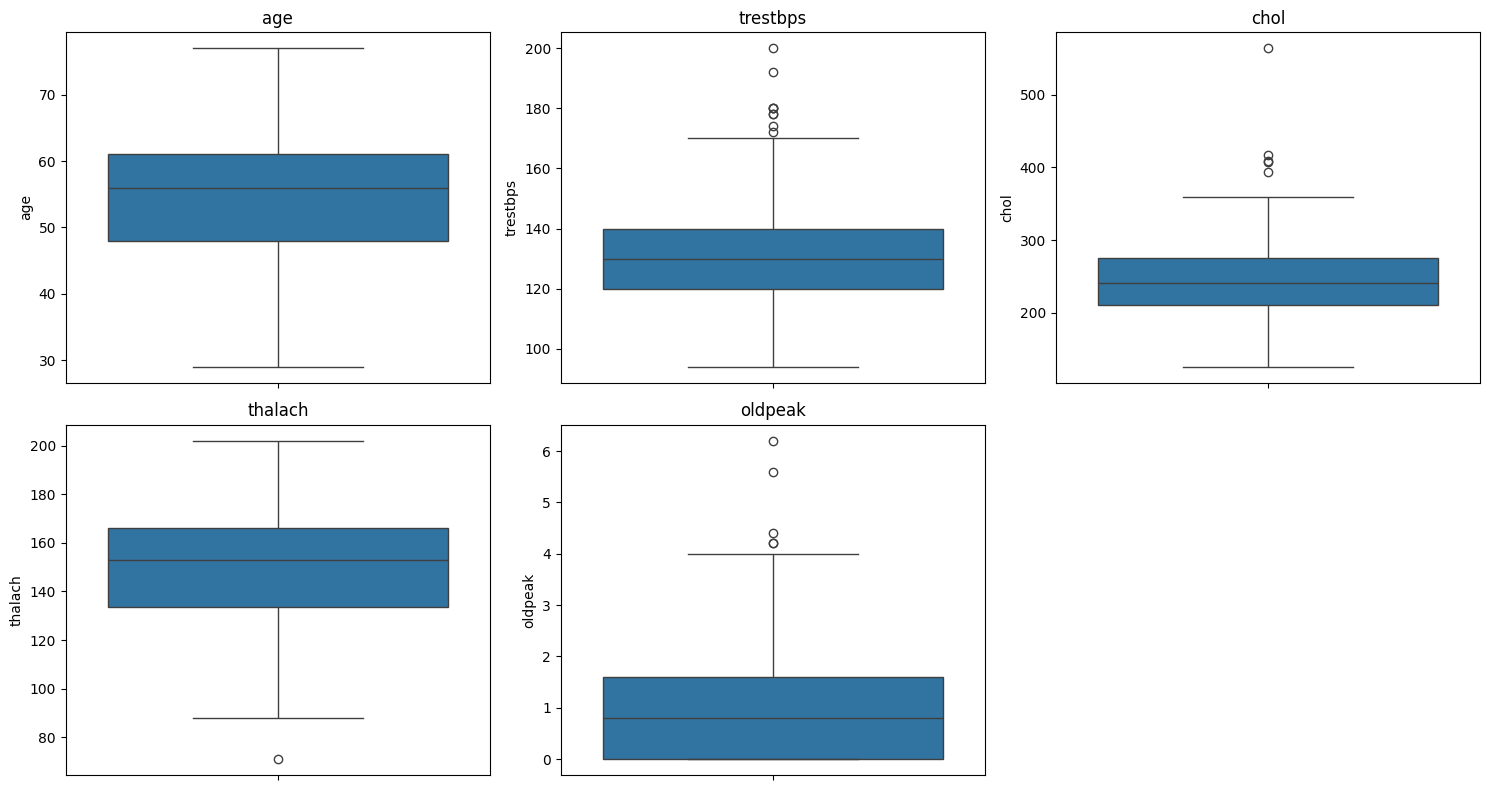

In [16]:
num_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

plt.figure(figsize=(15, 8))
for i, col in enumerate(num_cols, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(y=df[col])
    plt.title(col)
plt.tight_layout()
plt.show()

In [18]:
def count_outliers_iqr(data, col):
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = data[(data[col] < lower) | (data[col] > upper)]
    return len(outliers), lower, upper
    print("Outlier summary (IQR method):\n")
for col in num_cols:
    n_out, low, up = count_outliers_iqr(df, col)
    print(f"{col}: {n_out} outliers | valid range = [{low:.2f}, {up:.2f}]")

age: 0 outliers | valid range = [28.50, 80.50]
trestbps: 9 outliers | valid range = [90.00, 170.00]
chol: 5 outliers | valid range = [115.00, 371.00]
thalach: 1 outliers | valid range = [84.75, 214.75]
oldpeak: 5 outliers | valid range = [-2.40, 4.00]


In [19]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [20]:
def cap_outliers_iqr(data, col):
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    data[col] = np.where(data[col] < lower, lower,
                  np.where(data[col] > upper, upper, data[col]))
    return data

for col in num_cols:
    df = cap_outliers_iqr(df, col)

print("Outliers capped. Sample stats after capping:")
print(df[num_cols].describe())

Outliers capped. Sample stats after capping:
              age    trestbps        chol     thalach     oldpeak
count  303.000000  303.000000  303.000000  303.000000  303.000000
mean    54.438944  131.346535  245.584158  149.652640    1.024422
std      9.038662   16.648749   47.558803   22.731735    1.110127
min     29.000000   94.000000  126.000000   84.750000    0.000000
25%     48.000000  120.000000  211.000000  133.500000    0.000000
50%     56.000000  130.000000  241.000000  153.000000    0.800000
75%     61.000000  140.000000  275.000000  166.000000    1.600000
max     77.000000  170.000000  371.000000  202.000000    4.000000


In [21]:
X = df.drop(columns=['target'])
y = df['target']

print("\nFeature shape:", X.shape)
print("Target distribution:\n", y.value_counts())


Feature shape: (303, 12)
Target distribution:
 target
0    164
1    139
Name: count, dtype: int64


In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("\nTrain shape:", X_train.shape, "Test shape:", X_test.shape)


Train shape: (242, 12) Test shape: (61, 12)


In [24]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nScaling done. X_train_scaled sample:")
print(X_train_scaled[:3])


Scaling done. X_train_scaled sample:
[[-0.72948484  0.68313005  0.8701687  -0.39855965  0.53664447 -0.41119597
   1.0229958   0.71157307 -0.69617712 -0.45519142  0.67505958 -0.68971531]
 [ 0.05016647  0.68313005 -1.18427838 -0.03731832  0.28459602 -0.41119597
  -0.98157896  0.22176571 -0.69617712 -0.92755988 -0.9585846  -0.68971531]
 [-0.06121229 -1.46385011 -1.18427838  0.08309546  0.83070099  2.43193045
   1.0229958   0.39987747  1.43641607 -0.92755988 -0.9585846   0.44573438]]


In [25]:
!pip install xgboost catboost -q

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.3 MB/s eta 0:00:00


In [26]:
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train_scaled, y_train)
print("Logistic Regression trained.")

Logistic Regression trained.


In [27]:
rf_model = RandomForestClassifier(random_state=42, n_estimators=200)
rf_model.fit(X_train, y_train)  # tree models don't need scaling
print("Random Forest trained.")

Random Forest trained.


In [28]:
xgb_model = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')
xgb_model.fit(X_train, y_train)
print("XGBoost trained.")

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [20:56:46] WARNING: /__w/xgboost/xgboost/src/learner.cc:794: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost trained.


In [29]:
cat_model = CatBoostClassifier(random_state=42, verbose=0)
cat_model.fit(X_train, y_train)
print("CatBoost trained.")

print("\nAll 4 models trained successfully!")

CatBoost trained.

All 4 models trained successfully!


In [30]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

models = {
    "Logistic Regression": (lr_model, X_test_scaled),
    "Random Forest": (rf_model, X_test),
    "XGBoost": (xgb_model, X_test),
    "CatBoost": (cat_model, X_test)
}

results = []

for name, (model, X_te) in models.items():
    y_pred = model.predict(X_te)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    results.append([name, acc, prec, rec, f1])
    print(f"{name}: Accuracy={acc:.4f}, Precision={prec:.4f}, Recall={rec:.4f}, F1={f1:.4f}")


Logistic Regression: Accuracy=0.9180, Precision=0.8710, Recall=0.9643, F1=0.9153
Random Forest: Accuracy=0.9344, Precision=0.9000, Recall=0.9643, F1=0.9310
XGBoost: Accuracy=0.8525, Precision=0.7879, Recall=0.9286, F1=0.8525
CatBoost: Accuracy=0.9344, Precision=0.9000, Recall=0.9643, F1=0.9310


In [32]:
results_df = pd.DataFrame(results, columns=["Model", "Accuracy", "Precision", "Recall", "F1-score"])
results_df = results_df.round(4)

print("\n\nComparative Analysis Table:")
results_df



Comparative Analysis Table:


,Model,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,0.9180,0.8710,0.9643,0.9153
1,Random Forest,0.9344,0.9000,0.9643,0.9310
2,XGBoost,0.8525,0.7879,0.9286,0.8525
3,CatBoost,0.9344,0.9000,0.9643,0.9310


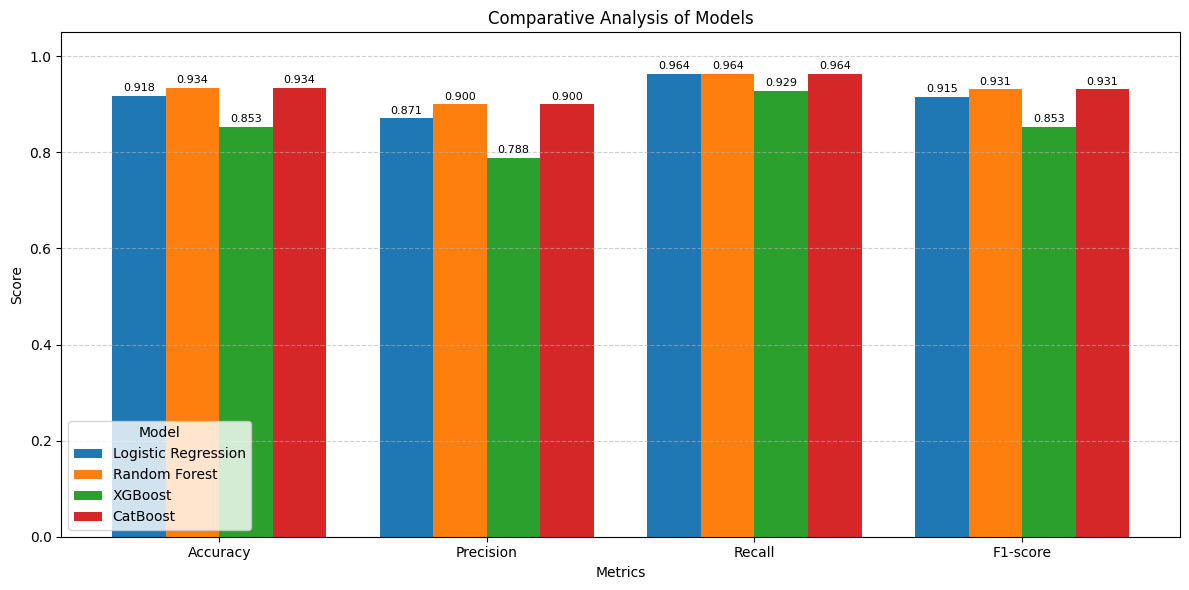

In [33]:
import matplotlib.pyplot as plt
import numpy as np

metrics = ["Accuracy", "Precision", "Recall", "F1-score"]
models_list = results_df["Model"].tolist()

x = np.arange(len(metrics))       # positions for metric groups
width = 0.2                       # width of each bar

fig, ax = plt.subplots(figsize=(12, 6))

for i, model in enumerate(models_list):
    values = results_df.loc[results_df["Model"] == model, metrics].values.flatten()
    ax.bar(x + i * width, values, width, label=model)

ax.set_xlabel("Metrics")
ax.set_ylabel("Score")
ax.set_title("Comparative Analysis of Models")
ax.set_xticks(x + width * (len(models_list) - 1) / 2)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.05)
ax.legend(title="Model")
ax.grid(axis='y', linestyle='--', alpha=0.6)

for i, model in enumerate(models_list):
    values = results_df.loc[results_df["Model"] == model, metrics].values.flatten()
    for j, v in enumerate(values):
        ax.text(x[j] + i * width, v + 0.01, f"{v:.3f}", ha='center', fontsize=8)

plt.tight_layout()
plt.show()